In [2]:
from __future__ import annotations
from pathlib import Path
from typing import Optional, Tuple, Dict

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import random

import matplotlib.pyplot as plt
from torchinfo import summary

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)

print("Using device:", device)

Using device: mps


In [10]:
def add_ghost_shadow_safe(
    clean: torch.Tensor,
    alpha: Optional[float] = None,
    dy: Optional[int] = None,
    dx: Optional[int] = None,
    max_shift: int = 1,
    allow_diagonal: bool = True,
    blur_sigma: float = 0.0,
    noise_std: float = 0.0,
    crop_safe: bool = True,
) -> Tuple[torch.Tensor, torch.Tensor, Dict]:
    """
    clean: (H,W) or (1,H,W) float in [0,1]
    returns: ghost, clean, meta (both possibly center-cropped by max_shift)
    """
    if clean.ndim == 2:
        clean = clean.unsqueeze(0)

    # choose random shift if not given
    if dy is None or dx is None:
        base = [(1,0),(-1,0),(0,1),(0,-1)]
        if allow_diagonal:
            base += [(1,1),(1,-1),(-1,1),(-1,-1)]
        dy0, dx0 = random.choice(base)
        s = 1 if max_shift <= 1 else random.randint(1, max_shift)
        dy, dx = dy0 * s, dx0 * s

    if alpha is None:
        alpha = random.uniform(0.25, 0.75)

    shifted = torch.roll(clean, shifts=(dy, dx), dims=(-2, -1))

    # optional blur on shifted copy only
    if blur_sigma > 0:
        k = max(3, int(round(blur_sigma * 6)) | 1)
        shifted = TF.gaussian_blur(shifted, kernel_size=[k, k], sigma=[blur_sigma, blur_sigma])

    ghost = (1.0 - alpha) * clean + alpha * shifted

    if noise_std > 0:
        ghost = ghost + torch.randn_like(ghost) * noise_std

    ghost = ghost.clamp(0, 1)

    # safe crop to remove wrap-around from roll
    if crop_safe and max_shift > 0:
        _, H, W = ghost.shape
        m = max_shift
        ghost = ghost[:, m:H-m, m:W-m]
        clean = clean[:, m:H-m, m:W-m]

    meta = {"alpha": float(alpha), "dy": int(dy), "dx": int(dx), "cropped_by": int(max_shift if crop_safe else 0)}
    return ghost, clean, meta


def random_crop_pair(img1: torch.Tensor, img2: torch.Tensor, crop_size: int):
    """
    Random crop same region from img1 and img2.
    Both must be (1,H,W).
    """
    _, H, W = img1.shape

    if H < crop_size or W < crop_size:
        raise ValueError("Crop size larger than image.")

    top = torch.randint(0, H - crop_size + 1, (1,)).item()
    left = torch.randint(0, W - crop_size + 1, (1,)).item()

    img1 = img1[:, top:top+crop_size, left:left+crop_size]
    img2 = img2[:, top:top+crop_size, left:left+crop_size]

    return img1, img2

class PatchNPYDataset(Dataset):
    """
    Loads pre-extracted patches from a .npy file (or .npz) and applies ghosting transform.

    Expected patch array shapes:
      - (N, H, W) uint8 or float
      - (N, H, W, 1) also OK

    Returns:
      ghost: (1,h,w) float32
      clean: (1,h,w) float32
      meta: dict
    """
    def __init__(
        self,
        patches_path: str | Path,
        dtype: torch.dtype = torch.float32,
        normalize: str = "uint8",   # "uint8" assumes 0..255 -> /255
        max_shift: int = 1,
        allow_diagonal: bool = True,
        alpha_range: Tuple[float, float] = (0.25, 0.75),
        blur_sigma_range: Tuple[float, float] = (0.0, 0.8),
        noise_std_range: Tuple[float, float] = (0.0, 0.0),  # in [0,1] units
        crop_safe: bool = True,
        random_flip_rot: bool = True,
        seed: Optional[int] = 0,
    ):
        self.patches_path = Path(patches_path)
        if not self.patches_path.exists():
            raise FileNotFoundError(self.patches_path)

        arr = np.load(self.patches_path, allow_pickle=False)
        # handle npz
        if isinstance(arr, np.lib.npyio.NpzFile):
            # take first key
            key = list(arr.keys())[0]
            arr = arr[key]

        if arr.ndim == 4 and arr.shape[-1] == 1:
            arr = arr[..., 0]
        if arr.ndim != 3:
            raise ValueError(f"Expected (N,H,W) or (N,H,W,1), got {arr.shape}")

        self.patches = arr
        self.dtype = dtype
        self.normalize = normalize

        self.max_shift = max_shift
        self.allow_diagonal = allow_diagonal
        self.alpha_range = alpha_range
        self.blur_sigma_range = blur_sigma_range
        self.noise_std_range = noise_std_range
        self.crop_safe = crop_safe

        self.random_flip_rot = random_flip_rot
        self.rng = random.Random(seed)

    def __len__(self) -> int:
        return self.patches.shape[0]

    def _to_tensor01(self, x_np: np.ndarray) -> torch.Tensor:
        x = torch.from_numpy(x_np)
        if x.ndim != 2:
            raise ValueError("Patch must be 2D after loading.")
        x = x.to(self.dtype)

        if self.normalize == "uint8":
            # assume 0..255
            x = x / 255.0
        elif self.normalize == "none":
            pass
        else:
            raise ValueError(f"Unknown normalize='{self.normalize}'")

        return x.clamp(0, 1)

    def _augment_geom(self, x: torch.Tensor) -> torch.Tensor:
        # x: (H,W) float
        if not self.random_flip_rot:
            return x
        # random 90° rotations
        k = self.rng.randint(0, 3)
        x = torch.rot90(x, k, dims=(0, 1))
        # random flips
        if self.rng.random() < 0.5:
            x = torch.flip(x, dims=(1,))  # horizontal
        if self.rng.random() < 0.5:
            x = torch.flip(x, dims=(0,))  # vertical
        return x

    def __getitem__(self, idx: int):
        clean_np = self.patches[idx]
        clean = self._to_tensor01(clean_np)
        clean = self._augment_geom(clean)

        alpha = self.rng.uniform(*self.alpha_range)
        # random shift direction + magnitude up to max_shift
        # base = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(-1,-1)]
        base = [(1,1)]
        if self.allow_diagonal:
            base += [(1,1),(1,-1),(-1,1),(-1,-1)]
        dy0, dx0 = self.rng.choice(base)
        s = 1 if self.max_shift <= 1 else self.rng.randint(1, self.max_shift)
        s = self.max_shift

        dy, dx = dy0 * s, dx0 * s

        blur_sigma = self.rng.uniform(*self.blur_sigma_range)
        noise_std = self.rng.uniform(*self.noise_std_range)

        ghost, clean_out, meta = add_ghost_shadow_safe(
            clean,
            alpha=alpha,
            dy=dy,
            dx=dx,
            max_shift=self.max_shift,
            allow_diagonal=self.allow_diagonal,
            blur_sigma=blur_sigma,
            noise_std=noise_std,
            crop_safe=self.crop_safe,
        )
        
        # Random Crop to 256
        ghost, clean_out = random_crop_pair(ghost, clean_out, crop_size=256)
        return ghost, clean_out, meta


def make_dataloader(
    patches_path: str | Path,
    batch_size: int = 8,
    num_workers: int = 0,
    shuffle: bool = True,
    pin_memory: bool = False,
    persistent_workers: bool = True,
    **dataset_kwargs,
) -> DataLoader:
    ds = PatchNPYDataset(patches_path, **dataset_kwargs)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(persistent_workers and num_workers > 0),
    )

In [8]:
def _safe_groups(num_channels: int, max_groups: int = 8) -> int:
    """Pick a GroupNorm group count that divides num_channels."""
    g = min(max_groups, num_channels)
    while g > 1 and (num_channels % g) != 0:
        g -= 1
    return max(g, 1)


class ResBlock(nn.Module):
    """Residual conv block with GroupNorm + SiLU. Starts near-identity."""
    def __init__(self, c_in: int, c_out: int, k: int = 3, max_groups: int = 8):
        super().__init__()
        p = k // 2
        g = _safe_groups(c_out, max_groups)

        self.conv1 = nn.Conv2d(c_in, c_out, k, padding=p)
        self.gn1   = nn.GroupNorm(g, c_out)
        self.act1  = nn.SiLU(inplace=True)

        self.conv2 = nn.Conv2d(c_out, c_out, k, padding=p)
        self.gn2   = nn.GroupNorm(g, c_out)
        self.act2  = nn.SiLU(inplace=True)

        self.skip  = nn.Identity() if c_in == c_out else nn.Conv2d(c_in, c_out, 1)

        # near-identity init (helps restoration)
        nn.init.zeros_(self.conv2.weight)
        if self.conv2.bias is not None:
            nn.init.zeros_(self.conv2.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.act1(self.gn1(self.conv1(x)))
        h = self.gn2(self.conv2(h))
        return self.act2(h + self.skip(x))


class Downsample(nn.Module):
    """Strided conv downsample + norm + activation."""
    def __init__(self, c_in: int, c_out: int, max_groups: int = 8):
        super().__init__()
        g = _safe_groups(c_out, max_groups)
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(g, c_out),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Upsample(nn.Module):
    """Transpose conv upsample by 2."""
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(c_in, c_out, kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.up(x)


class DeGhostUNet(nn.Module):
    """
    Residual U-Net for deghosting.

    - Input : ghost image (B, in_ch, H, W)  (default in_ch=1)
    - Output: residual (B, 1, H, W) where clean ≈ ghost + residual

    Notes:
    - No clamp in forward (clamp only for visualization/saving).
    - Works best when H,W are divisible by 2**depth (default depth=2 -> divisible by 4).
      If not, pad/crop outside.
    """
    def __init__(self, base: int = 48, in_ch: int = 1, max_groups: int = 8):
        super().__init__()
        self.in_ch = in_ch

        # Encoder
        self.enc1  = ResBlock(in_ch, base, max_groups=max_groups)
        self.down1 = Downsample(base, base * 2, max_groups=max_groups)
        self.enc2  = ResBlock(base * 2, base * 2, max_groups=max_groups)

        self.down2 = Downsample(base * 2, base * 4, max_groups=max_groups)
        self.mid1  = ResBlock(base * 4, base * 4, max_groups=max_groups)
        self.mid2  = ResBlock(base * 4, base * 4, max_groups=max_groups)

        # Decoder
        self.up2   = Upsample(base * 4, base * 2)
        self.dec2  = ResBlock(base * 4, base * 2, max_groups=max_groups)  # concat skip

        self.up1   = Upsample(base * 2, base)
        self.dec1  = ResBlock(base * 2, base, max_groups=max_groups)      # concat skip

        # Residual head
        self.out   = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, ghost: torch.Tensor) -> torch.Tensor:
        # Encoder
        s1 = self.enc1(ghost)           # (B, base, H, W)
        x  = self.down1(s1)             # (B, 2b, H/2, W/2)
        s2 = self.enc2(x)               # (B, 2b, H/2, W/2)

        x  = self.down2(s2)             # (B, 4b, H/4, W/4)
        x  = self.mid1(x)
        x  = self.mid2(x)

        # Decoder
        x  = self.up2(x)                # (B, 2b, H/2, W/2)
        x  = self.dec2(torch.cat([x, s2], dim=1))

        x  = self.up1(x)                # (B, b, H, W)
        x  = self.dec1(torch.cat([x, s1], dim=1))

        residual = self.out(x)          # (B,1,H,W)
        return residual

In [11]:

file_train = Path("../../data/promotion/245_004.adj.patches.train.npy")

file_val = Path("../../data/promotion/245_004.adj.patches.val.npy")

train_loader = make_dataloader(
        file_train,
        batch_size=16,
        num_workers=0,        # set >0 only if Dataset is in an importable .py module
        shuffle=True,
        pin_memory=(device.type == "cuda"),
        max_shift=8,
        alpha_range=(0.3, 0.7),
        blur_sigma_range=(0.0, 0.6),
        noise_std_range=(0.0, 0.01),
        crop_safe=True,
        random_flip_rot=True,
    )

val_loader = make_dataloader(
    file_val,
    batch_size=8,
    num_workers=0,
    shuffle=False,
    pin_memory=(device.type == "cuda"),
    max_shift=8,
    alpha_range=(0.3, 0.7),
    blur_sigma_range=(0.0, 0.6),
    noise_std_range=(0.0, 0.01),
    crop_safe=True,
    random_flip_rot=False,
)

## OverFitting Test

In [ ]:
# --- Model ---
model = DeGhostUNet(base=48)
summary(model,input_size=(1,1,256,256))

Layer (type:depth-idx)                   Output Shape              Param #
DeGhostUNet                              [1, 1, 256, 256]          --
├─ResBlock: 1-1                          [1, 48, 256, 256]         --
│    └─Conv2d: 2-1                       [1, 48, 256, 256]         480
│    └─GroupNorm: 2-2                    [1, 48, 256, 256]         96
│    └─SiLU: 2-3                         [1, 48, 256, 256]         --
│    └─Conv2d: 2-4                       [1, 48, 256, 256]         20,784
│    └─GroupNorm: 2-5                    [1, 48, 256, 256]         96
│    └─Conv2d: 2-6                       [1, 48, 256, 256]         96
│    └─SiLU: 2-7                         [1, 48, 256, 256]         --
├─Downsample: 1-2                        [1, 96, 128, 128]         --
│    └─Sequential: 2-8                   [1, 96, 128, 128]         --
│    │    └─Conv2d: 3-1                  [1, 96, 128, 128]         41,568
│    │    └─GroupNorm: 3-2               [1, 96, 128, 128]         192
│    

In [ ]:
model.to(device).train()

ghost, clean, _ = next(iter(train_loader))
ghost, clean = ghost[:4,::].to(device), clean[:4,::].to(device)

target_res = clean - ghost

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Overfit one batch ---
for i in range(3000):
    opt.zero_grad()
    pred_res = model(ghost)
    loss = F.l1_loss(pred_res, target_res)
    loss.backward()
    opt.step()

    if i % 50 == 0:
        pred_clean = ghost + pred_res
        rec = F.l1_loss(pred_clean, clean).item()
        print(i, "res_loss", float(loss.detach().cpu()), "rec_loss", rec)

# --- Evaluation ---
model.eval()

with torch.no_grad():
    pred_res = model(ghost)
    pred_clean = (ghost + pred_res).clamp(0, 1)

# --- Baseline identity loss ---
identity_loss = F.l1_loss(ghost, clean).item()
recon_loss = F.l1_loss(pred_clean, clean).item()

print("Identity loss:", identity_loss)
print("Reconstruction loss:", recon_loss)



0 res_loss 0.062327004969120026 rec_loss 0.062327004969120026
50 res_loss 0.022671818733215332 rec_loss 0.022671818733215332
100 res_loss 0.01598042994737625 rec_loss 0.01598042994737625
150 res_loss 0.013449964113533497 rec_loss 0.013449964113533497
200 res_loss 0.011850056238472462 rec_loss 0.011850056238472462
250 res_loss 0.010577778331935406 rec_loss 0.010577778331935406
300 res_loss 0.009444694966077805 rec_loss 0.009444694966077805
350 res_loss 0.009012453258037567 rec_loss 0.009012453258037567
400 res_loss 0.008209574036300182 rec_loss 0.008209574036300182
450 res_loss 0.007803045213222504 rec_loss 0.007803045213222504
500 res_loss 0.0076541593298316 rec_loss 0.0076541593298316
550 res_loss 0.007521701045334339 rec_loss 0.007521701045334339
600 res_loss 0.007247705943882465 rec_loss 0.007247705943882465
650 res_loss 0.007065568584948778 rec_loss 0.0070655690506100655
700 res_loss 0.0068649472668766975 rec_loss 0.0068649472668766975
750 res_loss 0.0066337427124381065 rec_loss 0.

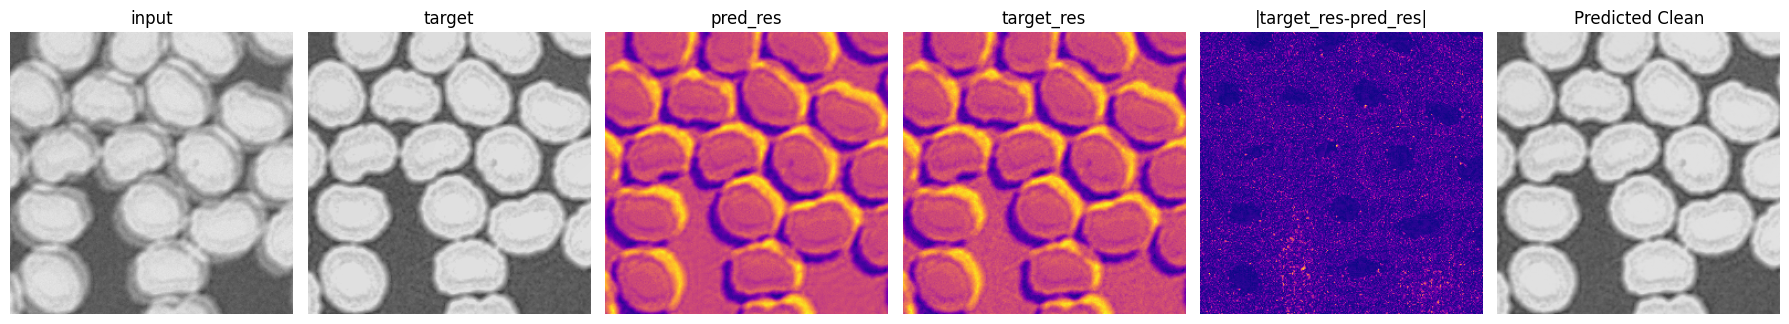

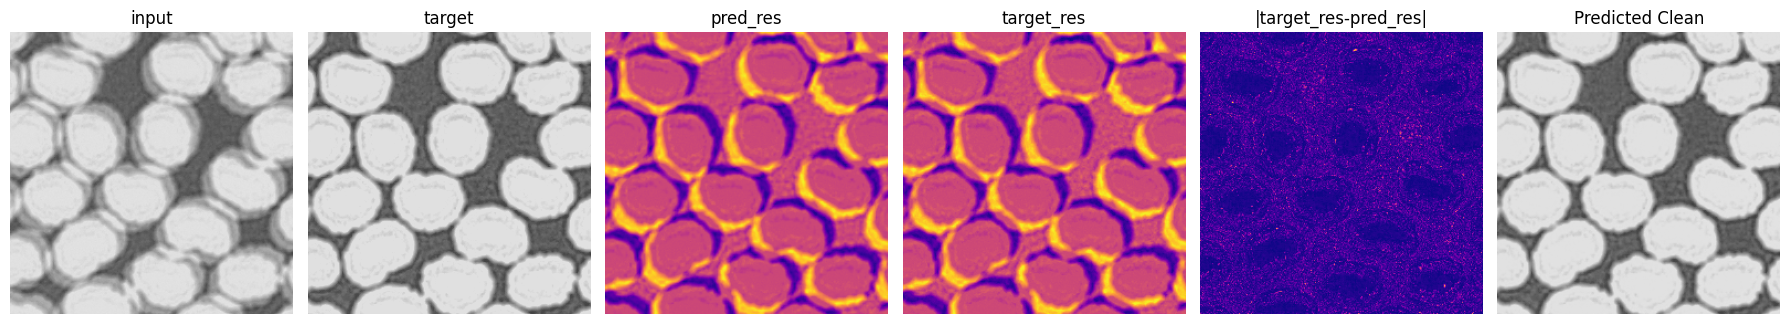

In [28]:
# --- Visual proof ---
bs = ghost.shape[0] # get batch size

for i in range(min(5,bs)):
    fig, axs = plt.subplots(1,6, figsize=(18,4))
    axs[0].imshow(ghost[i,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axs[0].set_title("input")

    axs[1].imshow(clean[i,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axs[1].set_title("target")

    axs[2].imshow(pred_res[i,0].cpu(), cmap="plasma")
    axs[2].set_title("pred_res")


    axs[3].imshow(target_res[i,0].cpu(), cmap="plasma")
    axs[3].set_title("target_res")

    axs[4].imshow((target_res-pred_res)[i,0].abs().cpu(), cmap="plasma")
    axs[4].set_title("|target_res-pred_res|")


    axs[5].imshow(pred_clean[i,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axs[5].set_title("Predicted Clean")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Train Utils

In [5]:
from dataclasses import dataclass

import time

@dataclass
class TrainConfig:
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 0.0
    grad_loss_w: float = 0.1
    log_every: int = 50
    amp: bool = True


@torch.no_grad()
def evaluate(model, loader, device, cfg: TrainConfig):
    model.eval()
    total = 0.0
    n = 0
    for ghost, clean, _meta in loader:
        ghost = ghost.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        pred = model(ghost)
        loss = F.l1_loss(pred, clean)
        if cfg.grad_loss_w > 0:
            loss = loss + cfg.grad_loss_w * gradient_l1(pred, clean)

        bs = ghost.size(0)
        total += float(loss) * bs
        n += bs
    return total / max(n, 1)

def train(model, train_loader, val_loader, device, cfg: TrainConfig):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    
    use_amp = (cfg.amp and device.type == "cuda")

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )

    history = {"train_loss": [], "val_loss": []}

    global_step = 0
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0 = time.time()

        running = 0.0
        seen = 0

        for ghost, clean, _meta in train_loader:
            ghost = ghost.to(device, non_blocking=True)
            clean = clean.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            
            with torch.amp.autocast(
                "cuda",
                enabled=use_amp
            ):
                pred = model(ghost)
                loss = F.l1_loss(pred, clean)
                if cfg.grad_loss_w > 0:
                    loss = loss + cfg.grad_loss_w * gradient_l1(pred, clean)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bs = ghost.size(0)
            running += float(loss.detach().item()) * bs
            seen += bs
            global_step += 1

            if cfg.log_every and (global_step % cfg.log_every == 0):
                print(f"epoch {epoch:03d} step {global_step:06d}  loss {running/max(seen,1):.5f}")

        train_loss = running / max(seen, 1)
        val_loss = evaluate(model, val_loader, device, cfg) if val_loader is not None else float("nan")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        dt = time.time() - t0
        print(f"[epoch {epoch:03d}] train {train_loss:.5f}  val {val_loss:.5f}  ({dt:.1f}s)")

    return history


0.2121783196926117 0.9305204153060913 torch.float32
0.0795145332813263


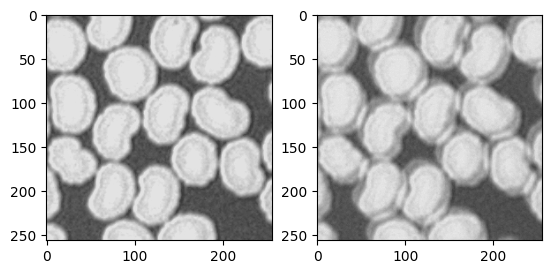

In [7]:
ghost, clean, _ = next(iter(train_loader))
print(ghost.min().item(), ghost.max().item(), ghost.dtype)

fig, axs = plt.subplots(1,2)

axs[0].imshow(clean[0,0,::],cmap="gray",vmin=0,vmax=1)
axs[1].imshow(ghost[0,0,::],cmap="gray",vmin=0,vmax=1)


loss = F.l1_loss(ghost,clean)

print(loss.detach().cpu().item())

In [8]:
cfg = TrainConfig(
    epochs=10,
    lr=1e-3,
    grad_loss_w=0.5,
    log_every=5,
    amp=False,
)

model = DeghostUNet(base=32, in_channels=1, predict_residual=False)


history = train(model, train_loader,val_loader, device, cfg)

# Optional: save model + history
torch.save({"model": model.state_dict(), "history": history}, "deghost_cnn.pt")
print("Saved checkpoint: deghost_cnn.pt")

epoch 001 step 000005  loss 0.43887
epoch 001 step 000010  loss 0.30955
epoch 001 step 000015  loss 0.25688
epoch 001 step 000020  loss 0.22814
[epoch 001] train 0.21727  val 0.14017  (11.1s)
epoch 002 step 000025  loss 0.13569
epoch 002 step 000030  loss 0.13032
epoch 002 step 000035  loss 0.12841
epoch 002 step 000040  loss 0.12612
epoch 002 step 000045  loss 0.12324
[epoch 002] train 0.12302  val 0.10685  (10.9s)
epoch 003 step 000050  loss 0.10715
epoch 003 step 000055  loss 0.10410
epoch 003 step 000060  loss 0.10405
epoch 003 step 000065  loss 0.10389
[epoch 003] train 0.10399  val 0.10057  (10.9s)
epoch 004 step 000070  loss 0.09735
epoch 004 step 000075  loss 0.10237
epoch 004 step 000080  loss 0.10161
epoch 004 step 000085  loss 0.10309
epoch 004 step 000090  loss 0.10214
[epoch 004] train 0.10230  val 0.09765  (11.0s)
epoch 005 step 000095  loss 0.10172
epoch 005 step 000100  loss 0.09838
epoch 005 step 000105  loss 0.09770
epoch 005 step 000110  loss 0.09784
epoch 005 step 0

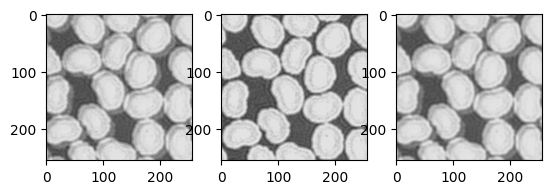

In [9]:
ghost, clean, _ = next(iter(train_loader))
model.eval()


with torch.no_grad():
    ghost = ghost.to(device, non_blocking=True)
    clean_ = model(ghost)

fig, axs = plt.subplots(1,3)


axs[0].imshow(ghost[0,0,::].cpu(),cmap="gray",vmin=0,vmax=1)

axs[1].imshow(clean[0,0,::].cpu(),cmap="gray",vmin=0,vmax=1)
axs[2].imshow(clean_[0,0,::].cpu(),cmap="gray",vmin=0,vmax=1)


In [63]:
model = TinyUNetResidual(base=48).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)


EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    tot = 0.0
    n = 0
    for ghost, clean, _ in train_loader:
        ghost, clean = ghost.to(device), clean.to(device)
        target_res = clean - ghost

        opt.zero_grad(set_to_none=True)
        pred_res = model(ghost)
        loss = F.l1_loss(pred_res, target_res)
        loss.backward()
        opt.step()

        bs = ghost.size(0)
        tot += loss.item() * bs
        n += bs

    print("epoch", epoch, "mean_loss", tot/n)



epoch 0 mean_loss 0.4657334604233668
epoch 1 mean_loss 0.0837410162743284
epoch 2 mean_loss 0.0759023035264147
epoch 3 mean_loss 0.07469810609247803
epoch 4 mean_loss 0.07686821770602169
epoch 5 mean_loss 0.07215340810092115
epoch 6 mean_loss 0.07357287151708129
epoch 7 mean_loss 0.0750867517778228
epoch 8 mean_loss 0.07330247370824629
epoch 9 mean_loss 0.07474447247567098
